In [1]:
# =========================================================
# Imports
# =========================================================
import os
import random
import datetime
from glob import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow.keras.backend as K

# =========================================================
# Global Parameters & Audio Logic
# =========================================================
OTHER_ROOT = "Noban/Other"
WAKE_ROOT  = "Noban/Wake"
NOISE_ROOT = "Noban/Noise"
TARGET_SR  = 16000
TARGET_LEN = 1 * TARGET_SR

# Spectrogram Config
N_MELS       = 32
N_FFT        = 512
HOP_LENGTH   = 320
LOOKBACK     = N_FFT - HOP_LENGTH   # 192 — samples carried between streaming chunks
FMIN         = 60
FMAX         = 6000
TARGET_WIDTH = 50

# Feature Selection
USE_PCEN     = True
NORMALIZE    = 'per_sample'
LOG_MEL      = False

# PCEN Constants
PCEN_ALPHA         = 0.90
PCEN_DELTA         = 2.0
PCEN_R             = 0.5
PCEN_TIME_C        = 0.10

# Streaming
STRIDE_LEN     = int(0.3 * TARGET_SR)   # 4800 — 300ms, must match inference
HEAD_TRIM_LEN  = 0                       # was 1600; sources are now natively 2.4s,
                                         # so no head-trim is needed
STREAM_LEN     = 8 * STRIDE_LEN          # 38400 = 2.4s — exactly 8 strides,
                                         # no trailing partial chunk

# Training & Augmentation
BATCH_SIZE      = 32
QAT_BATCH_SIZE  = 16
EPOCHS          = 100
DROPOUT_RATE    = 0.1

# SpecAugment Parameters
USE_SPECAUG     = True
TIME_MASK_MAX   = 10
FREQ_MASK_MAX   = 4

# Reproducibility
SEED = 99
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Setup complete. Mode: {'PCEN' if USE_PCEN else 'Log-Mel'}")


2026-06-19 10:49:35.720536: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 10:49:35.743911: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-19 10:49:36.070915: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Setup complete. Mode: PCEN


In [2]:
#cell 1
# =========================================================
# Audio Loading Utilities
# =========================================================
# Returns 2.4 s = 8 × STRIDE_LEN samples (pad short, truncate long). Audio
# length is exactly divisible by STRIDE_LEN, so the streaming feature
# extractor in cell 2 has no trailing partial chunk and matches the streaming
# inference recipe in cells 18 (FAR sim) and 19 (live mic) bit-for-bit.

def load_audio(path, sr=TARGET_SR):
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

    if audio is None or len(audio) == 0:
        return None

    if len(audio) < STREAM_LEN:
        audio = np.pad(audio, (0, STREAM_LEN - len(audio)))
    elif len(audio) > STREAM_LEN:
        audio = audio[:STREAM_LEN]

    if np.isnan(audio).any():
        return None

    return audio.astype(np.float32)


# =========================================================
# Load Dataset
# =========================================================

X_audio = []
y_labels = []
file_paths = []

wake_count = other_count = noise_count = 0

print("Loading wake-word files...")
wake_files = glob(os.path.join(WAKE_ROOT, "*.wav"))
for f in wake_files:
    audio = load_audio(f)
    if audio is not None:
        X_audio.append(audio)
        y_labels.append(0)
        file_paths.append(f)
        wake_count += 1

print("Loading noise files...")
noise_files = glob(os.path.join(NOISE_ROOT, "*.wav"))
for f in noise_files:
    audio = load_audio(f)
    if audio is not None:
        X_audio.append(audio)
        y_labels.append(2)
        file_paths.append(f)
        noise_count += 1

print("Loading other speech...")
other_files = glob(os.path.join(OTHER_ROOT, "*.wav"))
for f in other_files:
    audio = load_audio(f)
    if audio is not None:
        X_audio.append(audio)
        y_labels.append(1)
        file_paths.append(f)
        other_count += 1

X_audio = np.array(X_audio, dtype=np.float32)
y_labels = np.array(y_labels)

print("\nDataset loaded:")
print(f"  Wake:  {wake_count}")
print(f"  Other: {other_count}")
print(f"  Noise: {noise_count}")
print(f"  Total: {len(X_audio)}")
print(f"  Audio shape: {X_audio.shape}  (= {STREAM_LEN/TARGET_SR:.2f} s per clip)")


Loading wake-word files...


/home/mahrad/miniconda3/envs/ml/lib/python3.9/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Loading noise files...
Loading other speech...

Dataset loaded:
  Wake:  15520
  Other: 15520
  Noise: 15520
  Total: 46560
  Audio shape: (46560, 38400)  (= 2.40 s per clip)


In [3]:
#cell 2
#=========================================================
# Feature Extraction Functions for DS-CNN
# (SpecAugment runs on-the-fly via tf.data — see next cell.)
#=========================================================

# ── Pre-compute silence-warmed PCEN zi — run once ────────────────────────────
def _make_pcen_zi_init(time_c=PCEN_TIME_C, n_warmup=5):
    silence = np.zeros(TARGET_LEN, dtype=np.float32)
    mel_sil = librosa.feature.melspectrogram(
        y=silence, sr=TARGET_SR, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS,
        fmin=FMIN, fmax=FMAX, power=1.0, center=False
    )
    zi = None
    for _ in range(n_warmup):
        _, zi = librosa.pcen(
            S=mel_sil * (2**31),
            sr=TARGET_SR, hop_length=HOP_LENGTH,
            time_constant=time_c, gain=PCEN_ALPHA,
            bias=PCEN_DELTA, power=PCEN_R, eps=1e-3,
            zi=zi, return_zf=True
        )
    return zi

PCEN_ZI_INIT = _make_pcen_zi_init()
print("✅ PCEN warmup state ready")

# ─────────────────────────────────────────────────────────────────────────────
# Streaming PCEN feature extraction (matches inference exactly).
#
# For each 2.4 s clip:
#   - Slide a 50-frame mel ring buffer.
#   - Process audio in 8 STRIDE_LEN-sample (300 ms) chunks. Each chunk yields
#     15 new mel frames after the lookback prefix → 120 frames total.
#   - The ring buffer keeps the last 50 (= the most recent ~1 s of the clip).
#   - Final buffer is the model input.
#
# The inference cells (18 = FAR sim, 19 = live mic) feed extract_features
# ONE CHUNK PER STRIDE from the live audio queue. Same per-chunk math.
#
# IMPORTANT: training and inference are coupled. Both must use this recipe
# (or both must be reverted together). Changing one without the other shifts
# the feature distribution.
# ─────────────────────────────────────────────────────────────────────────────

def _stream_pcen_into_buffer(audio, zi, time_c, mel_buffer):
    """Feed `audio` into mel_buffer chunk by chunk; return updated buffer + zi.

    With n_fft > hop_length, frames overlap by (n_fft - hop_length) samples.
    To compute frames that span a chunk boundary, we prepend the last LOOKBACK
    samples of the previous chunk before each FFT pass. lookback starts as
    zeros (matches inference cold-start in cells 18, 19 and main.cpp)."""
    cursor = 0
    n = len(audio)
    lookback = np.zeros(LOOKBACK, dtype=np.float32)
    while cursor < n:
        end = min(cursor + STRIDE_LEN, n)
        chunk = audio[cursor:end]
        cursor = end
        input_audio = np.concatenate([lookback, chunk])
        if len(input_audio) < N_FFT:
            break  # not enough samples for one frame — nothing to add
        mel = librosa.feature.melspectrogram(
            y=input_audio, sr=TARGET_SR, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS,
            fmin=FMIN, fmax=FMAX, power=1.0, center=False
        )
        mel, zi = librosa.pcen(
            S=mel * (2**31),
            sr=TARGET_SR, hop_length=HOP_LENGTH,
            time_constant=time_c, gain=PCEN_ALPHA,
            bias=PCEN_DELTA, power=PCEN_R, eps=1e-3,
            zi=zi, return_zf=True
        )
        # Save last LOOKBACK samples of this chunk for next iteration's prefix
        if len(chunk) >= LOOKBACK:
            lookback = chunk[-LOOKBACK:].astype(np.float32).copy()
        else:
            lookback = np.concatenate([lookback, chunk])[-LOOKBACK:].astype(np.float32)
        new_frames = mel.T
        n_new = new_frames.shape[0]
        if n_new == 0:
            continue
        if n_new >= TARGET_WIDTH:
            mel_buffer = new_frames[-TARGET_WIDTH:].astype(np.float32)
        else:
            mel_buffer = np.roll(mel_buffer, -n_new, axis=0)
            mel_buffer[-n_new:] = new_frames
    return mel_buffer, zi


def extract_ds_cnn_mfe(audio):
    """Clean PCEN feature extraction (deployment-true config).
    SpecAugment is applied on-the-fly per batch via tf.data (next cell)."""
    if USE_PCEN:
        zi = PCEN_ZI_INIT.copy()
        mel_buffer = np.zeros((TARGET_WIDTH, N_MELS), dtype=np.float32)
        mel_buffer, _ = _stream_pcen_into_buffer(audio, zi, PCEN_TIME_C, mel_buffer)
        mel = mel_buffer
    else:
        # Non-PCEN path: simple log/power-mel of last 1 s. Not used when
        # USE_PCEN=True (the default); kept for completeness.
        target = audio[-TARGET_LEN:]
        mel = librosa.feature.melspectrogram(
            y=target, sr=TARGET_SR, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS,
            fmin=FMIN, fmax=FMAX, power=2.0, center=False
        )
        if LOG_MEL:
            mel = librosa.power_to_db(mel, ref=1.0, top_db=80.0)
        mel = mel.T

    if mel.shape[0] < TARGET_WIDTH:
        mel = np.pad(mel, ((TARGET_WIDTH - mel.shape[0], 0), (0, 0)))
    else:
        mel = mel[-TARGET_WIDTH:]

    if not USE_PCEN:
        mean, std = np.mean(mel), np.std(mel)
        mel = (mel - mean) / (std + 1e-9)

    return mel.astype(np.float32)


def format_ds_cnn(mfe):
    """Add channel dimension: (50, 32) -> (50, 32, 1)"""
    return mfe[..., np.newaxis]

# =========================================================
# Train / Eval / Test Split
# =========================================================
X_train_orig, X_temp, y_train_orig, y_temp, p_train_orig, p_temp = train_test_split(
    X_audio, y_labels, file_paths,
    test_size=0.20, stratify=y_labels, random_state=SEED
)

X_eval_orig, X_test_orig, y_eval, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

# =========================================================
# Feature Extraction — 1 clean PCEN copy per clip.
# (SpecAugment is applied on-the-fly per batch via tf.data — see next cell.)
# =========================================================
X_train = np.array([
    format_ds_cnn(extract_ds_cnn_mfe(a))
    for a in X_train_orig
], dtype=np.float32)
y_train = np.array(y_train_orig)

p_train_orig = np.array(p_train_orig)
X_train, y_train, p_train = shuffle(X_train, y_train, p_train_orig, random_state=SEED)

X_eval = np.array([
    format_ds_cnn(extract_ds_cnn_mfe(a))
    for a in X_eval_orig
], dtype=np.float32)

X_test = np.array([
    format_ds_cnn(extract_ds_cnn_mfe(a))
    for a in X_test_orig
], dtype=np.float32)

# =========================================================
# Class weights
# =========================================================
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weights)

# =========================================================
# Dataset shapes
# =========================================================
print("\nFeature extraction complete:")
print(f"  Train : {X_train.shape}, labels: {y_train.shape}")
print(f"  Eval  : {X_eval.shape},  labels: {y_eval.shape}")
print(f"  Test  : {X_test.shape},  labels: {y_test.shape}")

assert X_train.shape[1:] == (TARGET_WIDTH, N_MELS, 1), f"Train shape mismatch: {X_train.shape[1:]}"
assert X_eval.shape[1:]  == (TARGET_WIDTH, N_MELS, 1), f"Eval shape mismatch: {X_eval.shape[1:]}"
assert X_test.shape[1:]  == (TARGET_WIDTH, N_MELS, 1), f"Test shape mismatch: {X_test.shape[1:]}"
print("✅ All shapes confirmed (TARGET_WIDTH, N_MELS, 1)")


✅ PCEN warmup state ready
Class weights: {0: 1.0, 1: 1.0, 2: 1.0}

Feature extraction complete:
  Train : (37248, 50, 32, 1), labels: (37248,)
  Eval  : (4656, 50, 32, 1),  labels: (4656,)
  Test  : (4656, 50, 32, 1),  labels: (4656,)
✅ All shapes confirmed (TARGET_WIDTH, N_MELS, 1)


In [4]:
# =========================================================
# tf.data pipeline with on-the-fly SpecAugment
# =========================================================
# Fresh time/freq masks every batch every epoch — stronger regularization
# than baking a fixed set of augmented copies into X_train.

def tf_spec_augment(x, time_mask_max=TIME_MASK_MAX, freq_mask_max=FREQ_MASK_MAX,
                    n_time=2, n_freq=2):
    """SpecAugment on a batch (B, T, F, 1). Per-batch masks (one mask shared
    across the batch) — fast, GPU-friendly, good enough for regularization."""
    T = tf.shape(x)[1]
    F = tf.shape(x)[2]
    fill = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)  # per-sample mean

    def apply_mask(x_in, axis_len, max_w, axis):
        w  = tf.random.uniform([], 0, max_w + 1, dtype=tf.int32)
        w0 = tf.random.uniform([], 0, axis_len - w + 1, dtype=tf.int32)
        m  = tf.concat([tf.ones([w0]), tf.zeros([w]),
                        tf.ones([axis_len - w0 - w])], axis=0)
        shape = [1, 1, 1, 1]
        shape[axis] = -1
        m = tf.reshape(m, shape)
        return x_in * m + fill * (1.0 - m)

    for _ in range(n_time):
        x = apply_mask(x, T, time_mask_max, axis=1)
    for _ in range(n_freq):
        x = apply_mask(x, F, freq_mask_max, axis=2)
    return x


def make_train_dataset(X, y_oh, batch_size, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y_oh))
    ds = ds.shuffle(buffer_size=4096, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size, drop_remainder=False)
    if augment and USE_SPECAUG:
        ds = ds.map(lambda x, y: (tf_spec_augment(x), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


def make_eval_dataset(X, y_oh, batch_size):
    return (tf.data.Dataset.from_tensor_slices((X, y_oh))
            .batch(batch_size).prefetch(tf.data.AUTOTUNE))


print("✅ tf.data pipeline ready: SpecAugment runs on-the-fly during training")


✅ tf.data pipeline ready: SpecAugment runs on-the-fly during training


In [5]:
print("TensorFlow version:", tf.__version__)
# Convert labels to one-hot for Label Smoothing compatibility
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_eval_oh  = tf.keras.utils.to_categorical(y_eval, num_classes=3)
y_test_oh  = tf.keras.utils.to_categorical(y_test, num_classes=3)

TensorFlow version: 2.13.1


In [6]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Val")
    axes[0].set_title(f"{title} Accuracy")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Val")
    axes[1].set_title(f"{title} Loss")
    axes[1].legend()
    axes[1].grid()
    plt.show()
# =========================================================
# Constrained metric: FRR @ FAR budget
# Monitor: minimize misses while keeping false-alarms <= budget
# =========================================================
FAR_BUDGET = 0.001  # 0.1% (stricter to minimize false alarms)
_FRR_THRESHOLDS = np.round(np.linspace(0.02, 0.98, 49), 4).astype('float32')
class FRRAtFARBudget(tf.keras.metrics.Metric):
    """FRR (miss rate) at the highest threshold where FAR <= budget.
    Lower is better (mode="min"). Directly optimizes: minimize misses
    while keeping false alarms <= 0.1%."""
    def __init__(self, far_budget=FAR_BUDGET, thresholds=_FRR_THRESHOLDS, name="frr_at_far_budget", **kw):
        super().__init__(name=name, **kw)
        self.far_budget = far_budget
        self.th = tf.constant(thresholds, dtype=tf.float32)
        K = int(self.th.shape[0])
        self.miss = self.add_weight(name="miss", shape=(K,), initializer="zeros")
        self.fa   = self.add_weight(name="fa",   shape=(K,), initializer="zeros")
        self.nw   = self.add_weight(name="nw", initializer="zeros")
        self.nn   = self.add_weight(name="nn", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        pw = tf.cast(y_pred[:, 0], tf.float32)
        is_w = tf.equal(tf.argmax(y_true, -1), 0)
        fired = pw[:, None] >= self.th[None, :]
        wc = tf.cast(is_w, tf.float32)[:, None]; nc = tf.cast(tf.logical_not(is_w), tf.float32)[:, None]
        self.miss.assign_add(tf.reduce_sum(wc * tf.cast(tf.logical_not(fired), tf.float32), 0))
        self.fa.assign_add(tf.reduce_sum(nc * tf.cast(fired, tf.float32), 0))
        self.nw.assign_add(tf.reduce_sum(wc)); self.nn.assign_add(tf.reduce_sum(nc))
    def result(self):
        pmiss = tf.math.divide_no_nan(self.miss, self.nw)
        pfa = tf.math.divide_no_nan(self.fa, self.nn)
        # Find highest threshold where FAR <= budget, return FRR there
        valid = pfa <= self.far_budget
        if not tf.reduce_any(valid):
            return 1.0  # No valid threshold -> worst case
        frr_at_budget = tf.reduce_min(tf.where(valid, pmiss, 1.0))
        return frr_at_budget
    def reset_state(self):
        for v in (self.miss, self.fa): v.assign(tf.zeros_like(v))
        self.nw.assign(0.); self.nn.assign(0.)


In [7]:
# =============================================================================
# Model definition - Noban V17 (RF-corrected, QAT/TFLite-int8 ready)
# =============================================================================

def coord_attention(x, T_eff, F_eff, reduction=4):
    """Coordinate Attention (Hou et al. 2021), QAT/TFLite-safe form: each axis
    gets its own pooled, BN'd 1x1 bottleneck; the two logits are summed and
    passed through ONE fused sigmoid gate. No Lambda / Permute / Concatenate, so the
    selective quantize_apply wraps cleanly and int8 conversion succeeds. The BN
    in each bottleneck is the fix vs. the old un-normalised gate."""
    ch = x.shape[-1]
    r  = max(1, ch // reduction)

    # Time axis
    t = layers.AveragePooling2D((1, F_eff))(x)              # (B, T, 1, C)
    t = layers.Conv2D(r,  1, use_bias=False)(t)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)
    t_logit = layers.Conv2D(ch, 1, use_bias=False)(t)      # (B, T, 1, C)

    # Frequency axis
    f = layers.AveragePooling2D((T_eff, 1))(x)             # (B, 1, F, C)
    f = layers.Conv2D(r,  1, use_bias=False)(f)
    f = layers.BatchNormalization()(f)
    f = layers.ReLU()(f)
    f_logit = layers.Conv2D(ch, 1, use_bias=False)(f)      # (B, 1, F, C)

    # Fused single gate: sigmoid(t_logit + f_logit) instead of two separate
    # sigmoids multiplied. A product of two near-zero sigmoids is the most
    # int8-fragile op here (loses resolution near 0 -> isolated boundary
    # jitter / look-alike false-triggers). One gate removes that noise source.
    gate = layers.Activation('sigmoid')(layers.Add()([t_logit, f_logit]))
    return layers.Multiply()([x, gate])


def se_block(x, reduction=4):
    """Squeeze-Excite, QAT/TFLite-safe (GlobalAveragePooling2D instead of
    tf.reduce_mean; activations unfused from the convs)."""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(keepdims=True)(x)   # (B, 1, 1, C)
    se = layers.Conv2D(max(1, channels // reduction), 1, use_bias=False)(se)
    se = layers.ReLU()(se)
    se = layers.Conv2D(channels, 1, use_bias=False)(se)
    se = layers.Activation('sigmoid')(se)
    return layers.Multiply()([x, se])


# =============================================================================
# V17 - ACTIVE.
#
# Receptive-field guarantees (stride 1 everywhere, RF = 1 + sum (k-1)*d):
#   * ERF == RF (no gridding): HDC sawtooth [1,2,3,1,2,3] -> M2 = 2 <= kernel on
#     both axes (time k=5, freq k=3). Wang et al. 2018 HDC criterion.
#   * Full coverage: time RF = 1 + 5 + 4*12 = 54 >= 50;
#                    freq RF = 1 + 3 + 5 + 2*12 = 33 >= 32.
#
# Quantization notes:
#   * No raw TF ops, no Lambda -> selective quantize_apply (cell 8) wraps it.
#   * Conv->BN adjacency + use_bias=False everywhere -> BN folds in QAT.
#   * Activations unfused from Conv/Dense for clean fake-quant placement.
# =============================================================================
def build_model_v17(input_shape=(50, 32, 1), num_classes=3):
    T, F_bins = input_shape[0], input_shape[1]
    inputs = tf.keras.Input(shape=input_shape)

    # -- 1. Stem ----------------------------------------------------------------
    x = layers.Conv2D(32, (1, 4), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(32, (1, 6), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(32, (6, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

    # -- 2. DS-CNN blocks -------------------------------------------------------
    dilation_schedule = [(1, 1), (2, 2), (3, 3), (1, 1), (2, 2), (3, 3)]
    channel_schedule  = [32, 48, 48, 64, 64, 64]

    T_eff, F_eff = T, F_bins   # stride-1 everywhere -> constant

    for i, ((dil_t, dil_f), ch) in enumerate(zip(dilation_schedule, channel_schedule)):
        shortcut = x

        x_dw = layers.DepthwiseConv2D(
            (5, 3), padding='same',
            dilation_rate=(dil_t, dil_f),
            use_bias=False,
        )(x)
        x_dw = layers.BatchNormalization()(x_dw)
        x_dw = layers.ReLU()(x_dw)

        if i >= 3:
            x_dw = coord_attention(x_dw, T_eff, F_eff)

        x = layers.Conv2D(ch, (1, 1), padding='same', use_bias=False)(x_dw)
        x = layers.BatchNormalization()(x)

        if shortcut.shape[-1] != ch:
            shortcut = layers.Conv2D(ch, (1, 1), padding='same', use_bias=False)(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.Add()([x, shortcut])
        x = se_block(x)
        x = layers.ReLU()(x)

    # -- 2.5 Global coordinate-attention gate -----------------------------------
    x = coord_attention(x, T_eff, F_eff)

    # -- 3. Head ----------------------------------------------------------------
    x = layers.DepthwiseConv2D((1, F_eff), padding='valid', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

    x = layers.DepthwiseConv2D((T_eff, 1), padding='valid', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

    x = layers.Flatten()(x)

    # -- Classifier (single hidden FC) ------------------------------------------
    x = layers.Dense(64, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(num_classes, use_bias=True)(x)         # logits
    outputs = layers.Activation('softmax')(x)              # unfused for QAT

    return tf.keras.Model(inputs, outputs, name="Noban_V17")


# Active build function.
build_model = build_model_v17

model = build_model(input_shape=(TARGET_WIDTH, N_MELS, 1), num_classes=3)
model.summary()


2026-06-19 10:52:16.446884: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-19 10:52:16.457515: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-19 10:52:16.457628: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "Noban_V17"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 50, 32, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 50, 32, 32)           128       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 50, 32, 32)           128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 50, 32, 32)           0         ['batch_normalization[

In [8]:
os.makedirs("models", exist_ok=True)
steps_per_epoch = len(X_train) // BATCH_SIZE
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=steps_per_epoch * 5,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-4
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", FRRAtFARBudget()]
)
callbacks_fp32 = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=12,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        f"models/fp32_best_{timestamp}.h5",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]
print("Starting Phase 1: FP32 Training...")
train_ds_fp32 = make_train_dataset(X_train, y_train_oh, BATCH_SIZE, augment=True)
eval_ds       = make_eval_dataset (X_eval,  y_eval_oh,  BATCH_SIZE)
history_fp32 = model.fit(
    train_ds_fp32,
    validation_data=eval_ds,
    epochs=EPOCHS,
    callbacks=callbacks_fp32
)


Starting Phase 1: FP32 Training...
Epoch 1/100


2026-06-19 10:52:19.750328: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2026-06-19 10:52:20.942774: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-06-19 10:52:20.957068: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fc95cc25ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-19 10:52:20.957088: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2026-06-19 10:52:20.960298: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-19 10:52:21.017404: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p

1164/1164 [==============================] - ETA: 0s - loss: 0.6771 - accuracy: 0.7784 - frr_at_far_budget: 0.9613
Epoch 1: val_accuracy improved from -inf to 0.90335, saving model to models/fp32_best_20260619_104936.h5
1164/1164 [==============================] - 149s 118ms/step - loss: 0.6771 - accuracy: 0.7784 - frr_at_far_budget: 0.9613 - val_loss: 0.4883 - val_accuracy: 0.9034 - val_frr_at_far_budget: 0.3280
Epoch 2/100


/home/mahrad/miniconda3/envs/ml/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1164/1164 [==============================] - ETA: 0s - loss: 0.5126 - accuracy: 0.8835 - frr_at_far_budget: 0.7227
Epoch 2: val_accuracy improved from 0.90335 to 0.93428, saving model to models/fp32_best_20260619_104936.h5
1164/1164 [==============================] - 138s 118ms/step - loss: 0.5126 - accuracy: 0.8835 - frr_at_far_budget: 0.7227 - val_loss: 0.4253 - val_accuracy: 0.9343 - val_frr_at_far_budget: 0.1527
Epoch 3/100
1164/1164 [==============================] - ETA: 0s - loss: 0.4678 - accuracy: 0.9115 - frr_at_far_budget: 0.6861
Epoch 3: val_accuracy improved from 0.93428 to 0.95425, saving model to models/fp32_best_20260619_104936.h5
1164/1164 [==============================] - 138s 119ms/step - loss: 0.4678 - accuracy: 0.9115 - frr_at_far_budget: 0.6861 - val_loss: 0.3926 - val_accuracy: 0.9543 - val_frr_at_far_budget: 0.0973
Epoch 4/100
1164/1164 [==============================] - ETA: 0s - loss: 0.4416 - accuracy: 0.9263 - frr_at_far_budget: 0.5246
Epoch 4: val_accuracy

In [9]:
def apply_quantization_to_supported_layers(layer):
    if isinstance(layer, (
        tf.keras.layers.Conv2D,
        tf.keras.layers.DepthwiseConv2D,
        tf.keras.layers.Dense
    )):
        return tfmot.quantization.keras.quantize_annotate_layer(layer)
    return layer

annotated_model = tf.keras.models.clone_model(
    model,
    clone_function=apply_quantization_to_supported_layers,
)

with tfmot.quantization.keras.quantize_scope({}):
    qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", FRRAtFARBudget()]
)


Starting Phase 2: QAT Fine-Tuning...
Epoch 1/50
2328/2328 [==============================] - ETA: 0s - loss: 0.3661 - accuracy: 0.9684 - frr_at_far_budget: 0.2814
Epoch 1: val_accuracy improved from -inf to 0.97186, saving model to models-dscnnqat/qat_best_acc_20260619_104936.h5
2328/2328 [==============================] - 307s 125ms/step - loss: 0.3661 - accuracy: 0.9684 - frr_at_far_budget: 0.2814 - val_loss: 0.3526 - val_accuracy: 0.9719 - val_frr_at_far_budget: 0.0058 - lr: 1.0000e-04
Epoch 2/50
2328/2328 [==============================] - ETA: 0s - loss: 0.3646 - accuracy: 0.9689 - frr_at_far_budget: 0.2676
Epoch 2: val_accuracy improved from 0.97186 to 0.97895, saving model to models-dscnnqat/qat_best_acc_20260619_104936.h5
2328/2328 [==============================] - 290s 124ms/step - loss: 0.3646 - accuracy: 0.9689 - frr_at_far_budget: 0.2676 - val_loss: 0.3391 - val_accuracy: 0.9790 - val_frr_at_far_budget: 0.0019 - lr: 1.0000e-04
Epoch 3/50
2328/2328 [========================

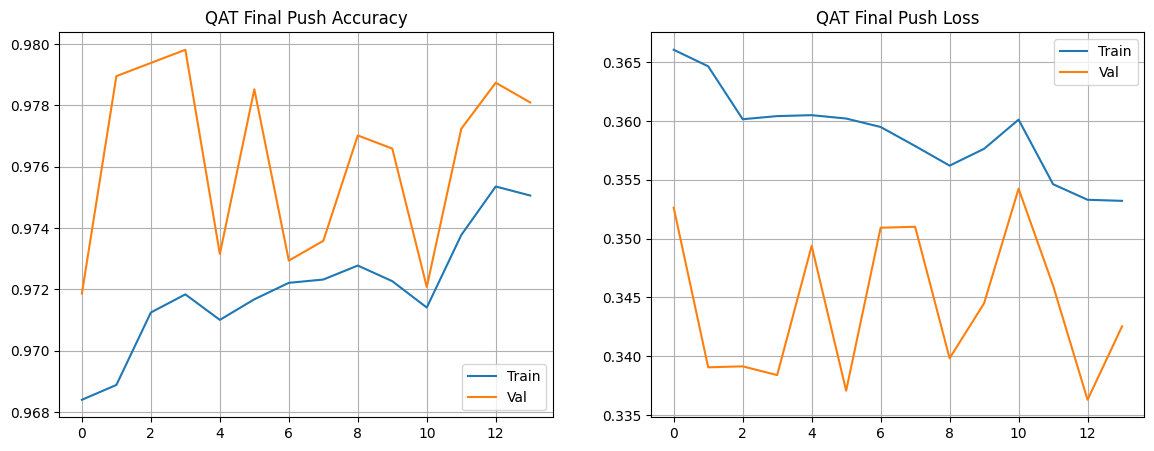

In [10]:
os.makedirs("models-dscnnqat", exist_ok=True)
callbacks_qat = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        f"models-dscnnqat/qat_best_acc_{timestamp}.h5",
        monitor="val_accuracy",
        verbose=1,
        mode="max",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        mode="max",
        verbose=1
    )
]
print("Starting Phase 2: QAT Fine-Tuning...")
qat_train_ds = make_train_dataset(X_train, y_train_oh, QAT_BATCH_SIZE, augment=True)
qat_eval_ds  = make_eval_dataset (X_eval,  y_eval_oh,  QAT_BATCH_SIZE)
history_qat = qat_model.fit(
    qat_train_ds,
    validation_data=qat_eval_ds,
    epochs=50,
    callbacks=callbacks_qat
)
plot_history(history_qat, "QAT Final Push")


146/146 [==============================] - 6s 39ms/step - loss: 0.3380 - accuracy: 0.9779 - frr_at_far_budget: 0.0013
Test accuracy: 0.9778780341148376
146/146 [==============================] - 5s 30ms/step
Best threshold: 0.40, Best F1: 0.9781
              precision    recall  f1-score   support

   Wake-word       1.00      1.00      1.00      1552
       Other       0.98      0.96      0.97      1552
       Noise       0.96      0.98      0.97      1552

    accuracy                           0.98      4656
   macro avg       0.98      0.98      0.98      4656
weighted avg       0.98      0.98      0.98      4656



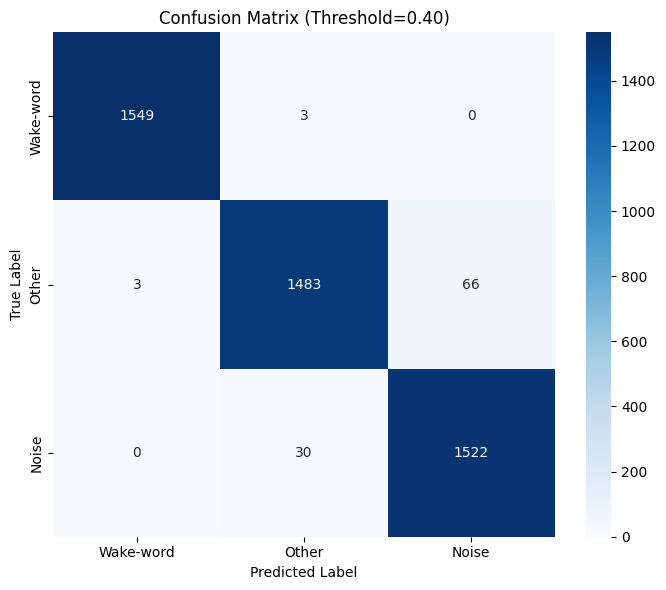


Test set: 1552 wake / 3104 not-wake
 thresh |  FRR(miss) | FAR(false-trig) | cost=FRR+5*FAR
   0.30 |      0.001 |           0.002 |    0.011
   0.35 |      0.001 |           0.001 |    0.008
   0.40 |      0.002 |           0.001 |    0.007
   0.45 |      0.002 |           0.001 |    0.007
   0.50 |      0.003 |           0.001 |    0.007
   0.55 |      0.005 |           0.001 |    0.008
   0.60 |      0.008 |           0.001 |    0.011
   0.65 |      0.010 |           0.000 |    0.011
   0.70 |      0.011 |           0.000 |    0.013
   0.75 |      0.013 |           0.000 |    0.013
   0.80 |      0.017 |           0.000 |    0.017
   0.85 |      0.023 |           0.000 |    0.023
   0.90 |      0.053 |           0.000 |    0.053
   0.95 |      0.531 |           0.000 |    0.531

Best deploy threshold = 0.40  ->  FRR=0.002  FAR=0.001  cost=0.007
NOTE: clip-level proxy. TRUE streaming FRR/FAR come from the EMA sim (cell 18).


In [11]:
FT_PENALTY = 5.0

results = qat_model.evaluate(X_test, y_test_oh)
test_loss, test_acc = results[0], results[1]
print("Test accuracy:", test_acc)

qat_model.save(f"models-dscnnqat/final_{timestamp}.h5")

# Predict probabilities
y_probs = qat_model.predict(X_test)

# Class info
class_names = ["Wake-word", "Other", "Noise"]
wake_word_class = 0  # index of Wake-word

# Try different thresholds
thresholds = np.linspace(0.1, 0.9, 17)

best_f1 = 0
best_threshold = 0.5
best_preds = None

from sklearn.metrics import f1_score

for t in thresholds:
    # Apply threshold ONLY on wake-word class
    y_pred = []
    for probs in y_probs:
        if probs[wake_word_class] >= t:
            y_pred.append(wake_word_class)
        else:
            # fallback to best of remaining classes
            other_classes = probs.copy()
            other_classes[wake_word_class] = -1
            y_pred.append(np.argmax(other_classes))
    
    y_pred = np.array(y_pred)
    
    f1 = f1_score(y_test, y_pred, average="macro")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
        best_preds = y_pred

print(f"Best threshold: {best_threshold:.2f}, Best F1: {best_f1:.4f}")

# Final evaluation with best threshold
print(classification_report(y_test, best_preds, target_names=class_names))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

# =========================================================
# Wake-centric report — FRR (miss) & FAR (false-trigger) vs threshold.
# other/noise are collapsed into "not-wake". Pick the deploy threshold that
# minimises  cost = FRR + FT_PENALTY * FAR  (same objective as val_wake_cost).
# =========================================================
is_wake_te = (y_test == 0)
n_wake = max(1, int(np.sum(is_wake_te)))
n_neg  = max(1, int(np.sum(~is_wake_te)))
print(f"\nTest set: {n_wake} wake / {n_neg} not-wake")
print(f"{'thresh':>7} | {'FRR(miss)':>10} | {'FAR(false-trig)':>15} | "
      f"cost=FRR+{FT_PENALTY:.0f}*FAR")
best_cost, best_t = 1e9, 0.5
for t in np.linspace(0.30, 0.95, 14):
    fired = y_probs[:, 0] >= t
    frr = np.sum(is_wake_te & ~fired) / n_wake
    far = np.sum(~is_wake_te & fired) / n_neg
    cost = frr + FT_PENALTY * far
    if cost < best_cost:
        best_cost, best_t = cost, t
    print(f"{t:7.2f} | {frr:10.3f} | {far:15.3f} | {cost:8.3f}")
fired = y_probs[:, 0] >= best_t
frr = np.sum(is_wake_te & ~fired) / n_wake
far = np.sum(~is_wake_te & fired) / n_neg
print(f"\nBest deploy threshold = {best_t:.2f}  ->  FRR={frr:.3f}  FAR={far:.3f}  cost={best_cost:.3f}")
print("NOTE: clip-level proxy. TRUE streaming FRR/FAR come from the EMA sim (cell 18).")

In [12]:
other_indices = np.where(y_test == 1)[0]  # class 1 = other
other_preds = qat_model.predict(X_test[other_indices])
fp_mask = np.argmax(other_preds, axis=1) == 0  # predicted as wake
fp_indices = other_indices[fp_mask]
fp_preds = other_preds[fp_mask]

# Print wake probability for each false positive
for i, idx in enumerate(fp_indices):
    prob = fp_preds[i]
    print(f"Sample {idx}: wake_prob={prob[0]:.4f}")


49/49 [==============================] - 1s 29ms/step
Sample 513: wake_prob=0.7265
Sample 1442: wake_prob=0.6253
Sample 1459: wake_prob=0.3648
Sample 1601: wake_prob=0.5151


In [13]:
# =========================================================
# Representative dataset for INT8 calibration - CLEAN audio only.
# =========================================================
# Quant ranges should reflect deployment-true input, so we calibrate on
# non-augmented clips:
#   * Wake : only originals (filename contains 'orig'); the '_augN' clips are
#            disk-level augmentations and are excluded.
#   * Other / Noise : no augmentation exists, so all are eligible.
# Class-balanced (up to N_PER_CLASS each) so wake activations are represented
# and not drowned out by the much larger noise/other pools.
# Requires p_train from cell 2 (file paths threaded through split + shuffle).

N_PER_CLASS = 100   # 100 x 3 = 300 calibration samples

_paths = [os.path.basename(str(p)).lower() for p in p_train]

def _is_clean(i):
    lbl = int(y_train[i])
    if lbl == 0:                       # wake
        return 'orig' in _paths[i]     # keep only original wake clips
    return True                        # other / noise are always clean

_calib_idx = {0: [], 1: [], 2: []}
for i in range(len(X_train)):
    lbl = int(y_train[i])
    if _is_clean(i) and len(_calib_idx[lbl]) < N_PER_CLASS:
        _calib_idx[lbl].append(i)

_calib_indices = _calib_idx[0] + _calib_idx[1] + _calib_idx[2]
assert len(_calib_indices) > 0, "No clean calibration samples found - check p_train / naming"

print(f"Calibration set (clean only): "
      f"wake-orig={len(_calib_idx[0])}, other={len(_calib_idx[1])}, "
      f"noise={len(_calib_idx[2])}, total={len(_calib_indices)}")

def representative_dataset():
    for i in _calib_indices:
        yield [X_train[i:i+1].astype(np.float32)]


Calibration set (clean only): wake-orig=100, other=100, noise=100, total=300


In [14]:
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Force FULL INT8 quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

print("INT8 conversion complete!")

INFO:tensorflow:Assets written to: /tmp/tmp5t34cpjd/assets


INFO:tensorflow:Assets written to: /tmp/tmp5t34cpjd/assets
/home/mahrad/miniconda3/envs/ml/lib/python3.9/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-06-19 13:38:03.857337: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-06-19 13:38:03.857353: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-06-19 13:38:03.857573: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp5t34cpjd
2026-06-19 13:38:03.881946: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-06-19 13:38:03.881967: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmp5t34cpjd
2026-06-19 13:38:03.944305: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimizatio

INT8 conversion complete!


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [15]:
tflite_path        = f"models-dscnnqat/dscnn_int8_{timestamp}.tflite"
tflite_latest_path = "models-dscnnqat/dscnn_int8_latest.tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_int8)
with open(tflite_latest_path, "wb") as f:
    f.write(tflite_int8)

print("Saved:", tflite_path)
print("Saved:", tflite_latest_path)


Saved: models-dscnnqat/dscnn_int8_20260619_104936.tflite
Saved: models-dscnnqat/dscnn_int8_latest.tflite


In [16]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype:", input_details[0]['dtype'])
print("Output dtype:", output_details[0]['dtype'])

print("Input quantization:", input_details[0]['quantization'])
print("Output quantization:", output_details[0]['quantization'])

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: (0.020822960883378983, -128)
Output quantization: (0.00390625, -128)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [17]:
size_kb = os.path.getsize(tflite_path) / 1024
print(f"Model size: {size_kb:.2f} KB")

Model size: 181.58 KB


In [18]:
# =========================================================
# Load DNC + OTHER datasets
# =========================================================

from glob import glob
import os

DNC_ROOT = "/home/mahrad/storage/Data/wake/WUW-final/Wake Up Word/DNC_reconstructed"
OTHER_ROOT = "/home/mahrad/storage/Data/wake/WUW-final/Wake Up Word/all other"

print("Loading dataset file paths...")

dnc_files = glob(os.path.join(DNC_ROOT, "*.wav"))
other_files = glob(os.path.join(OTHER_ROOT, "*.wav"))

print("DNC files:", len(dnc_files))
print("OTHER files:", len(other_files))

all_negatives = dnc_files + other_files

print("Total negative files:", len(all_negatives))

Loading dataset file paths...
DNC files: 4363
OTHER files: 349429
Total negative files: 353792


In [19]:
import os
import shutil
import tqdm
import numpy as np
import librosa
import tensorflow as tf
import soundfile as sf

# ── Parameters: same as live inference ────────────────────────────────────────
TFLITE_PATH = "models-dscnnqat/dscnn_int8_latest.tflite"

SAMPLE_RATE   = 16000
N_FFT         = 512
HOP_LENGTH    = 320
LOOKBACK      = N_FFT - HOP_LENGTH   # 192 — samples carried between streaming chunks
N_MELS        = 32
FMIN          = 60
FMAX          = 6000
TARGET_WIDTH  = 50
USE_PCEN      = True
LOG_MEL       = False                # must match training's LOG_MEL
PCEN_ALPHA    = 0.90
PCEN_DELTA    = 2.0
PCEN_R        = 0.5
PCEN_TIME_C   = 0.10

ALPHA            = 0.3        # 0.3/0.60 = high-recall; 0.4/0.70 = high-precision
THRESHOLD_UP     = 0.60       # EMA wake-prob fire threshold
THRESHOLD_DOWN   = 0.30       # Schmitt re-arm: EMA must dip below this to refire
MARGIN_MIN       = 0.20       # ema_wake - max(ema_other, ema_noise) — kills near-tie fires
COOLDOWN_FRAMES  = 7          # hard backstop
STRIDE_MS        = 300
STRIDE_SAMPLES   = int((STRIDE_MS / 1000) * SAMPLE_RATE)   # 4800
WINDOW_SAMPLES   = int(1.0 * SAMPLE_RATE)                  # 16000 (warmup only)
# NOTE: no head-trim here — this cell processes long, variable-length negative
# audio for false-alarm-rate estimation. Training's load_audio just pads/
# truncates to a fixed 2.4 s; that alignment doesn't apply to streams.

# ── Load TFLite model ─────────────────────────────────────────────────────────
if not os.path.exists(TFLITE_PATH):
    raise FileNotFoundError(f"TFLite model not found: {TFLITE_PATH}")

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale,  input_zero_point  = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("✅ TFLite model loaded")
print(f"   Input  quant : scale={input_scale:.6f}, zero_point={input_zero_point}")
print(f"   Output quant : scale={output_scale:.6f}, zero_point={output_zero_point}")


# ── Stateful streaming PCEN + mel ring buffer ─────────────────────────────────
# Initial mel_buffer is np.zeros, matching training (cell 2). Initial zi is
# silence-warmed via 5 PCEN passes. Both training and inference start from
# identical state, so feature math is bit-identical for the same audio.
class StreamingPCEN:
    def __init__(self, n_warmup=5):
        self.zi = self._make_warmed_zi(n_warmup)
        self.mel_buffer = np.zeros((TARGET_WIDTH, N_MELS), dtype=np.float32)
        self.lookback = np.zeros(LOOKBACK, dtype=np.float32)

    def reset(self):
        self.zi = self._make_warmed_zi()
        self.mel_buffer = np.zeros((TARGET_WIDTH, N_MELS), dtype=np.float32)
        self.lookback = np.zeros(LOOKBACK, dtype=np.float32)

    def _make_warmed_zi(self, n_warmup=5):
        silence = np.zeros(WINDOW_SAMPLES, dtype=np.float32)
        mel_sil = librosa.feature.melspectrogram(
            y=silence, sr=SAMPLE_RATE, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS,
            fmin=FMIN, fmax=FMAX, power=1.0, center=False
        )
        zi = None
        for _ in range(n_warmup):
            _, zi = librosa.pcen(
                S=mel_sil * (2**31),
                sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                time_constant=PCEN_TIME_C, gain=PCEN_ALPHA,
                bias=PCEN_DELTA, power=PCEN_R, eps=1e-3,
                zi=zi, return_zf=True
            )
        return zi


# ── Per-stride feature extraction ─────────────────────────────────────────────
def extract_features(new_chunk, pcen_state):
    # Prepend lookback so frames spanning the chunk boundary get computed.
    # Matches training (cell 2 _stream_pcen_into_buffer).
    input_audio = np.concatenate([pcen_state.lookback, new_chunk])

    mel = librosa.feature.melspectrogram(
        y=input_audio, sr=SAMPLE_RATE, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS,
        fmin=FMIN, fmax=FMAX,
        power=1.0 if USE_PCEN else 2.0,
        center=False
    )

    # Save last LOOKBACK samples of this chunk for next call's prefix
    if len(new_chunk) >= LOOKBACK:
        pcen_state.lookback = new_chunk[-LOOKBACK:].astype(np.float32).copy()
    else:
        pcen_state.lookback = np.concatenate(
            [pcen_state.lookback, new_chunk]
        )[-LOOKBACK:].astype(np.float32)

    if USE_PCEN:
        mel, pcen_state.zi = librosa.pcen(
            S=mel * (2**31),
            sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            time_constant=PCEN_TIME_C, gain=PCEN_ALPHA,
            bias=PCEN_DELTA, power=PCEN_R, eps=1e-3,
            zi=pcen_state.zi, return_zf=True
        )
        new_frames = mel.T
    else:
        new_frames = mel.T
        if LOG_MEL:
            new_frames = librosa.power_to_db(new_frames, ref=1.0, top_db=80.0)

    n_new = new_frames.shape[0]
    if n_new >= TARGET_WIDTH:
        pcen_state.mel_buffer = new_frames[-TARGET_WIDTH:].astype(np.float32)
    elif n_new > 0:
        pcen_state.mel_buffer = np.roll(pcen_state.mel_buffer, -n_new, axis=0)
        pcen_state.mel_buffer[-n_new:] = new_frames

    out = pcen_state.mel_buffer
    if not USE_PCEN:
        mean, std = np.mean(out), np.std(out)
        out = (out - mean) / (std + 1e-9)

    return out[np.newaxis, ..., np.newaxis].astype(np.float32)


# ── TFLite inference ──────────────────────────────────────────────────────────
def run_tflite(features_float32):
    x = features_float32 / input_scale + input_zero_point
    x = np.clip(x, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], x)
    interpreter.invoke()

    out = interpreter.get_tensor(output_details[0]["index"])
    out = (out.astype(np.float32) - output_zero_point) * output_scale
    return out


# ── Saved-clip simulation ─────────────────────────────────────────────────────
FAILURES_SIM_DIR = "failures_sim"
os.makedirs(FAILURES_SIM_DIR, exist_ok=True)


def full_dataset_ema_simulation(negative_paths):
    total_false_alarms  = 0
    total_audio_seconds = 0

    print(f"Starting saved-clip EMA simulation — fires saved to {FAILURES_SIM_DIR}/")
    print(f"    α={ALPHA}  up={THRESHOLD_UP}  down={THRESHOLD_DOWN}  "
          f"margin>{MARGIN_MIN}  cooldown={COOLDOWN_FRAMES}")
    print("=" * 45)

    for f in tqdm.tqdm(negative_paths):
        try:
            audio, _ = librosa.load(f, sr=SAMPLE_RATE, mono=True)
        except Exception:
            continue

        # Skip files shorter than 2.4 s (STREAM_LEN equivalent — too short to
        # form a fully-populated mel buffer the way training does).
        if audio is None or len(audio) < int(2.4 * SAMPLE_RATE):
            continue

        total_audio_seconds += len(audio) / SAMPLE_RATE

        pcen_state    = StreamingPCEN()
        ema_probs     = np.zeros(3, dtype=np.float32)   # [wake, other, noise]
        cooldown      = 0
        schmitt_armed = True   # cleared on fire, set when ema_wake dips below THRESHOLD_DOWN

        for stride_start in range(0, len(audio) - STRIDE_SAMPLES + 1, STRIDE_SAMPLES):
            new_chunk = audio[stride_start:stride_start + STRIDE_SAMPLES].astype(np.float32)
            features  = extract_features(new_chunk, pcen_state)
            preds     = run_tflite(features)[0]                          # (wake, other, noise)
            ema_probs = ALPHA * preds + (1.0 - ALPHA) * ema_probs

            ema_wake = float(ema_probs[0])
            margin   = ema_wake - float(max(ema_probs[1], ema_probs[2]))

            # Schmitt re-arm
            if not schmitt_armed and ema_wake < THRESHOLD_DOWN:
                schmitt_armed = True

            if cooldown > 0:
                cooldown -= 1

            if (cooldown == 0 and schmitt_armed
                    and ema_wake > THRESHOLD_UP
                    and margin > MARGIN_MIN):
                total_false_alarms += 1
                schmitt_armed = False
                cooldown      = COOLDOWN_FRAMES

                # Copy the source file (keep its original name) into the
                # failures dir as a hard-negative candidate. Once per file —
                # subsequent fires from the same file are no-ops because the
                # destination already exists.
                dst_path = os.path.join(FAILURES_SIM_DIR, os.path.basename(f))
                if not os.path.exists(dst_path):
                    try:
                        shutil.copy2(f, dst_path)
                    except Exception:
                        pass

    hours = total_audio_seconds / 3600
    print("\n" + "=" * 45)
    print("EMA simulation results")
    print("-" * 45)
    print(f"Total audio tested:  {hours:.2f} hours")
    print(f"False alarms:        {total_false_alarms}")
    if hours > 0:
        print(f"False alarms / hour: {total_false_alarms / hours:.4f}")
    print("=" * 45)


full_dataset_ema_simulation(all_negatives)


✅ TFLite model loaded
   Input  quant : scale=0.020823, zero_point=-128
   Output quant : scale=0.003906, zero_point=-128
Starting saved-clip EMA simulation — fires saved to failures_sim/
    α=0.3  up=0.6  down=0.3  margin>0.2  cooldown=7


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 353792/353792 [7:09:00<00:00, 13.74it/s]


EMA simulation results
---------------------------------------------
Total audio tested:  387.95 hours
False alarms:        3
False alarms / hour: 0.0077


In [ ]:
import numpy as np
import sounddevice as sd
import librosa
import queue
import tensorflow as tf

# ── Parameters ────────────────────────────────────────────────────────────────
TFLITE_PATH = "models-dscnnqat/dscnn_int8_latest.tflite"

SAMPLE_RATE  = 16000
N_FFT        = 512
HOP_LENGTH   = 320
LOOKBACK     = N_FFT - HOP_LENGTH   # 192 — samples carried between streaming chunks
N_MELS       = 32
FMIN         = 60
FMAX         = 6000
TARGET_WIDTH = 50
USE_PCEN     = True
LOG_MEL      = False                # must match training's LOG_MEL
PCEN_ALPHA   = 0.90
PCEN_DELTA   = 2.0
PCEN_R       = 0.5
PCEN_TIME_C  = 0.10        # must match training

ALPHA            = 0.3        # 0.3/0.60 = high-recall; 0.4/0.70 = high-precision
THRESHOLD_UP     = 0.60       # EMA wake-prob fire threshold (current value at fire)
THRESHOLD_DOWN   = 0.30       # Schmitt re-arm: EMA must dip below this to refire
MARGIN_MIN       = 0.20       # ema_wake - max(ema_other, ema_noise) — kills near-tie fires
STRIDE_MS        = 300                                          # must match training
STRIDE_SAMPLES   = int((STRIDE_MS / 1000) * SAMPLE_RATE)        # 4800
WINDOW_SAMPLES   = int(1.0 * SAMPLE_RATE)                       # 16000 (warmup only)
COOLDOWN_FRAMES  = 7          # hard backstop in addition to Schmitt re-arm

# ── Load TFLite model ─────────────────────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale,  input_zero_point  = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

print(f"✅ TFLite model loaded")
print(f"   Input  quant : scale={input_scale:.6f}, zero_point={input_zero_point}")
print(f"   Output quant : scale={output_scale:.6f}, zero_point={output_zero_point}")

# ── Audio queue ───────────────────────────────────────────────────────────────
audio_queue = queue.Queue()

def mic_callback(indata, frames, time_info, status):
    audio_queue.put(indata[:, 0].copy())

# ── Stateful streaming PCEN + mel ring buffer ─────────────────────────────────
# Initial mel_buffer is np.zeros, matching training (cell 2). zi is silence-
# warmed. Both sides start from identical state.
class StreamingPCEN:
    def __init__(self, n_warmup=5):
        self.zi = self._make_warmed_zi(n_warmup)
        self.mel_buffer = np.zeros((TARGET_WIDTH, N_MELS), dtype=np.float32)
        self.lookback = np.zeros(LOOKBACK, dtype=np.float32)
        print(f"✅ PCEN warmed up ({n_warmup} silence passes); mel_buffer = zeros (matches training)")

    def reset(self):
        self.zi = self._make_warmed_zi()
        self.mel_buffer = np.zeros((TARGET_WIDTH, N_MELS), dtype=np.float32)
        self.lookback = np.zeros(LOOKBACK, dtype=np.float32)

    def _make_warmed_zi(self, n_warmup=5):
        silence = np.zeros(WINDOW_SAMPLES, dtype=np.float32)
        mel_sil = librosa.feature.melspectrogram(
            y=silence, sr=SAMPLE_RATE, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS,
            fmin=FMIN, fmax=FMAX, power=1.0, center=False
        )
        zi = None
        for _ in range(n_warmup):
            _, zi = librosa.pcen(
                S=mel_sil * (2**31),
                sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                time_constant=PCEN_TIME_C, gain=PCEN_ALPHA,
                bias=PCEN_DELTA, power=PCEN_R, eps=1e-3,
                zi=zi, return_zf=True
            )
        return zi

# ── Per-stride feature extraction ─────────────────────────────────────────────
def extract_features(new_chunk, pcen_state):
    # Prepend lookback so frames spanning the chunk boundary get computed.
    # Matches training (cell 2 _stream_pcen_into_buffer).
    input_audio = np.concatenate([pcen_state.lookback, new_chunk])

    mel = librosa.feature.melspectrogram(
        y=input_audio, sr=SAMPLE_RATE, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS,
        fmin=FMIN, fmax=FMAX,
        power=1.0 if USE_PCEN else 2.0,
        center=False
    )

    # Save last LOOKBACK samples of this chunk for next call's prefix
    if len(new_chunk) >= LOOKBACK:
        pcen_state.lookback = new_chunk[-LOOKBACK:].astype(np.float32).copy()
    else:
        pcen_state.lookback = np.concatenate(
            [pcen_state.lookback, new_chunk]
        )[-LOOKBACK:].astype(np.float32)

    if USE_PCEN:
        mel, pcen_state.zi = librosa.pcen(
            S=mel * (2**31),
            sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            time_constant=PCEN_TIME_C, gain=PCEN_ALPHA,
            bias=PCEN_DELTA, power=PCEN_R, eps=1e-3,
            zi=pcen_state.zi, return_zf=True
        )
        new_frames = mel.T
    else:
        new_frames = mel.T
        if LOG_MEL:
            new_frames = librosa.power_to_db(new_frames, ref=1.0, top_db=80.0)

    n_new = new_frames.shape[0]
    if n_new >= TARGET_WIDTH:
        pcen_state.mel_buffer = new_frames[-TARGET_WIDTH:].astype(np.float32)
    elif n_new > 0:
        pcen_state.mel_buffer = np.roll(pcen_state.mel_buffer, -n_new, axis=0)
        pcen_state.mel_buffer[-n_new:] = new_frames

    out = pcen_state.mel_buffer
    if not USE_PCEN:
        mean, std = np.mean(out), np.std(out)
        out = (out - mean) / (std + 1e-9)

    return out[np.newaxis, ..., np.newaxis].astype(np.float32)

# ── TFLite inference ──────────────────────────────────────────────────────────
def run_tflite(features_float32):
    x = features_float32 / input_scale + input_zero_point
    x = np.clip(x, -128, 127).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    return (out.astype(np.float32) - output_zero_point) * output_scale

# ── Inference loop ────────────────────────────────────────────────────────────
def run_live_inference():
    pcen_state    = StreamingPCEN()
    ema_probs     = np.zeros(3, dtype=np.float32)   # [wake, other, noise]
    cooldown      = 0
    schmitt_armed = True   # cleared on fire, set when ema_wake dips below THRESHOLD_DOWN

    print("🎙️  Listening... (Ctrl+C to stop)")
    print(f"    α={ALPHA}  up={THRESHOLD_UP}  down={THRESHOLD_DOWN}  "
          f"margin>{MARGIN_MIN}  cooldown={COOLDOWN_FRAMES}")
    print("=" * 60)

    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype='float32',
        blocksize=STRIDE_SAMPLES,
        callback=mic_callback
    ):
        while True:
            try:
                new_chunk = audio_queue.get(timeout=1.0)
            except queue.Empty:
                continue

            features  = extract_features(new_chunk, pcen_state)
            preds     = run_tflite(features)[0]                       # (wake, other, noise)
            ema_probs = ALPHA * preds + (1.0 - ALPHA) * ema_probs

            ema_wake = float(ema_probs[0])
            margin   = ema_wake - float(max(ema_probs[1], ema_probs[2]))

            # Schmitt re-arm
            if not schmitt_armed and ema_wake < THRESHOLD_DOWN:
                schmitt_armed = True

            if cooldown > 0:
                cooldown -= 1

            arm = "ARM" if schmitt_armed else "off"
            print(f"  w={ema_wake:.2f} m={margin:.2f} {arm} cd={cooldown}",
                  end="\r")

            if (cooldown == 0 and schmitt_armed
                    and ema_wake > THRESHOLD_UP
                    and margin > MARGIN_MIN):
                schmitt_armed = False
                cooldown      = COOLDOWN_FRAMES
                print(f"\n🔔 WAKE WORD DETECTED! "
                      f"(ema_w={ema_wake:.3f}, margin={margin:.3f})")

# ── Run ────────────────────────────────────────────────────────────────────────
try:
    run_live_inference()
except KeyboardInterrupt:
    print("\n✅ Stopped.")


✅ TFLite model loaded
   Input  quant : scale=0.020823, zero_point=-128
   Output quant : scale=0.003906, zero_point=-128
✅ PCEN warmed up (5 silence passes); mel_buffer = zeros (matches training)
🎙️  Listening... (Ctrl+C to stop)
    α=0.3  up=0.6  down=0.3  margin>0.2  cooldown=7
  w=0.03 m=-0.92 ARM cd=0